**Download the PlantVillage Dataset:**

We will use the standard PlantVillage dataset from Kaggle, which is pre-split into training and validation folders. Put this code in your first cell to download it:



In [8]:
import kagglehub
import os

# Download the PlantVillage dataset
dataset_path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", dataset_path)

# Let's check the contents of the downloaded folder
train_dir = os.path.join(dataset_path, "New Plant Diseases Dataset(Augmented)", "New Plant Diseases Dataset(Augmented)", "train")
valid_dir = os.path.join(dataset_path, "New Plant Diseases Dataset(Augmented)", "New Plant Diseases Dataset(Augmented)", "valid")

print(f"Training directory exists: {os.path.exists(train_dir)}")
print(f"Validation directory exists: {os.path.exists(valid_dir)}")

Path to dataset files: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset
Training directory exists: True
Validation directory exists: True


**Data Augmentation and Image Generators:**

Deep learning models can easily memorize training images exactly as they are, which leads to poor performance on real-world data (a problem called overfitting). To prevent this, we use Data Augmentation. We configure TensorFlow to randomly rotate, shift, shear, and flip our training images slightly every time they pass through the model. Finally, we use flow_from_directory to load our images efficiently in batches directly from the Kaggle folders.

In [9]:
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# 1. Define standard image size for ResNet50 and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Setting up data augmentation for training...")

# 2. Training Data Generator with Augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # ResNet50's specific way of scaling pixels
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 3. Validation Data Generator
# We ONLY preprocess the validation images; we NEVER augment the test data!
valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

print("Loading images from directories...")

# 4. Load the images directly from the folders
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical' # Because we have multiple disease classes
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# 5. Save the class names (disease names) to use later in our web app
class_names = list(train_generator.class_indices.keys())
print(f"\nSuccessfully loaded {len(class_names)} different plant/disease categories!")

2026-03-08 05:38:53.967822: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772948334.152224      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772948334.208518      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772948334.653386      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772948334.653423      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772948334.653426      55 computation_placer.cc:177] computation placer alr

Setting up data augmentation for training...
Loading images from directories...
Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.

Successfully loaded 38 different plant/disease categories!


**Transfer Learning with ResNet50:**

In this step, we download the ResNet50 model, which has already been pre-trained on millions of everyday images. We will remove its original final layer and replace it with our own custom neural network "head" designed specifically for our plant disease categories. By freezing the base model, we keep all its pre-learned ability to detect visual features (like edges, textures, and shapes), saving us massive amounts of compute time.

In [10]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# 1. Load the pre-trained ResNet50 model (without its original classification head)
print("Downloading ResNet50 base model...")
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the base model layers
# We do this so we don't accidentally destroy the pre-trained weights during the first few epochs
for layer in base_model.layers:
    layer.trainable = False

# 3. Add our custom classification head
# Stacking these dense layers on top of a base CNN architecture will feel very
# familiar to building custom image classifiers for other visual tasks like waste sorting.
x = base_model.output
x = GlobalAveragePooling2D()(x)          # Condenses the feature maps into a 1D vector
x = Dense(256, activation='relu')(x)     # A fully connected layer to learn disease patterns
x = Dropout(0.5)(x)                      # Drops 50% of connections randomly to prevent overfitting

# 4. Add the final output layer
# We use 'softmax' to output probabilities for our specific number of classes
num_classes = len(class_names)
predictions = Dense(num_classes, activation='softmax')(x)

# 5. Combine everything into our final model
resnet_model = Model(inputs=base_model.input, outputs=predictions)

print(f"\nModel architecture ready! Custom head added for {num_classes} plant classes.")
# Uncomment the line below if you want to see the massive list of all the layers
# resnet_model.summary()

I0000 00:00:1772948380.641398      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772948380.647489      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Model architecture ready! Custom head added for 38 plant classes.


**Compiling and Training the Model:**

Now that our model architecture is complete, we need to compile it by defining the optimizer (how it learns) and the loss function (how it measures its mistakes). We will use the Adam optimizer and Categorical Crossentropy.

We are also introducing Callbacks. Deep learning models can sometimes get worse if you train them for too long (overfitting). To prevent this, we use EarlyStopping to halt training if the model stops improving, and ModelCheckpoint to automatically save the absolute best version of the model to our server.

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam

# 1. Compile the model
# We use the Adam optimizer and Categorical Crossentropy since we have multiple distinct classes
resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Set up Callbacks
# EarlyStopping: Stops training if the validation accuracy doesn't improve for 3 consecutive epochs
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

# ModelCheckpoint: Saves the best version of our model automatically as an .h5 file
checkpoint = ModelCheckpoint(
    'best_resnet_plant_model.h5',
    monitor='val_accuracy',
    save_best_only=True
)

print("Starting the GPU training process... This might take a little while!")

# 3. Train the model
# We set it to 10 epochs, but it might stop earlier thanks to EarlyStopping.
# Ensure your Colab runtime is set to T4 GPU before running this!
history = resnet_model.fit(
    train_generator,
    epochs=10,
    validation_data=valid_generator,
    callbacks=[early_stop, checkpoint]
)

print("\nTraining complete! The best model weights have been saved as 'best_resnet_plant_model.h5'.")

Starting the GPU training process... This might take a little while!


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1772948391.639063     158 service.cc:152] XLA service 0x7fc68c04d7c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772948391.639102     158 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772948391.639108     158 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772948393.564125     158 cuda_dnn.cc:529] Loaded cuDNN version 91002


   2/2197 ━━━━━━━━━━━━━━━━━━━━ 3:33 97ms/step - accuracy: 0.0469 - loss: 4.7671  

...

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1256s 566ms/step - accuracy: 0.6877 - loss: 1.0894 - val_accuracy: 0.9443 - val_loss: 0.1615
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.8878 - loss: 0.3408

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 904s 412ms/step - accuracy: 0.8878 - loss: 0.3408 - val_accuracy: 0.9545 - val_loss: 0.1290
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.9039 - loss: 0.2945

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 889s 405ms/step - accuracy: 0.9039 - loss: 0.2945 - val_accuracy: 0.9557 - val_loss: 0.1308
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.9124 - loss: 0.2620

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 925s 421ms/step - accuracy: 0.9124 - loss: 0.2620 - val_accuracy: 0.9611 - val_loss: 0.1160
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9167 - loss: 0.2571

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 919s 418ms/step - accuracy: 0.9167 - loss: 0.2571 - val_accuracy: 0.9653 - val_loss: 0.1019
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 916s 417ms/step - accuracy: 0.9217 - loss: 0.2429 - val_accuracy: 0.9602 - val_loss: 0.1161
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 907s 413ms/step - accuracy: 0.9255 - loss: 0.2269 - val_accuracy: 0.9601 - val_loss: 0.1183
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 882s 401ms/step - accuracy: 0.9308 - loss: 0.2161 - val_accuracy: 0.9597 - val_loss: 0.1281

Training complete! The best model weights have been saved as 'best_resnet_plant_model.h5'.


**Visualizing Performance and Saving to Drive:**

After training, it is crucial to plot the training and validation metrics. If the training accuracy keeps going up but the validation accuracy flattens out or drops, it means the model is overfitting. Once we confirm the model learned correctly, we will save the .h5 model weights and the list of disease class names directly to Google Drive so they can be loaded into our web backend later.

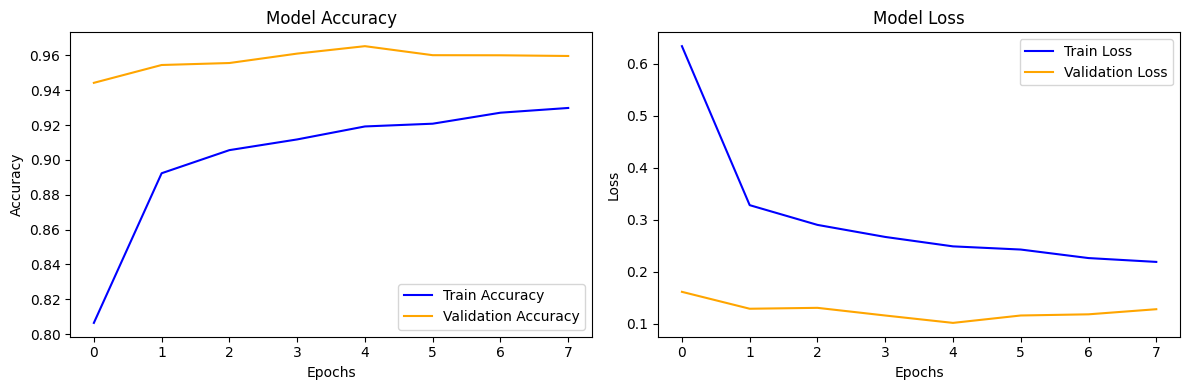

['plant_disease_classes.pkl']

In [12]:
import matplotlib.pyplot as plt
import shutil
import joblib
import os

# 1. Plot Training vs Validation Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 2. Plot Training vs Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

**SAVE THE MODEL**

In [14]:
# 3. Save the class names list
# Our web app needs this to translate the model's numerical output (e.g., "Class 4")
# back into the readable disease name (e.g., "Tomato_Bacterial_spot")
joblib.dump(class_names, 'plant_disease_classes.pkl')

['plant_disease_classes.pkl']